# Jupyter - Day 11 - Section 001
# Lec 11: More Logistic Regression

In this module we are going to test out the logistic regression classification method we discussed in class, but now we have:
- more than one input variable (multiple logistic regression) and,
- more than one level for the output variable (multinomial logistic regression).  

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Same as last time, we're going to use the `Default` data set from the ISLR book as included in their R package.  I've included a csv on the [DataSets page](../../DataSets/DataSets.md) for you to use. 

In [3]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)
Default.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625070
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880
5,No,Yes,919.588531,7491.558572
6,No,No,825.513331,24905.226580
7,No,Yes,808.667504,17600.451340
8,No,No,1161.057854,37468.529290
9,No,No,0.000000,29275.268290


In [4]:
# Here's all the entries in the "default" column
list(Default['default'].unique())

['No', 'Yes']

## Multiple Logistic Regression 

We're going to be training models of the form 

$$
p(X) = \frac{\exp(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p)}{1+\exp(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p )}
$$


This time, we are going to use all three input variables to predict `default`. 
First things first, `student` is a categorical input variable. Let's deal with that. 

&#9989; **<font color=red>Do this:</font>** Add a dummy variable column called `student_Yes` to your data frame and remove the `student` column. Before moving on, make sure my check below prints out `True`. 

In [6]:
##ANSWER##
Default['student_Yes'] = pd.get_dummies(Default['student'], drop_first = True, prefix='student')
Default.drop('student', axis=1, inplace=True)
Default.head()

# pd.get_dummies(Default['student'], drop_first = True, prefix='student').head()

,default,balance,income,student_Yes
0,No,729.526495,44361.62507,False
1,No,817.180407,12106.13470,True
2,No,1073.549164,31767.13895,False
3,No,529.250605,35704.49394,False
4,No,785.655883,38463.49588,False


In [7]:
# Check to see if you did that right!
# If your data frame is updated properly, this should print out True
list(Default.columns) == ['default', 'balance', 'income', 'student_Yes']

True

If you did all that right, the following should get us our train/test split of our inputs and outputs. 

In [8]:
X = Default[['balance', 'income', 'student_Yes']]
y = Default['default']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


&#9989; **<font color=red>Do this:</font>** Set up a logistic regression model using inputs `balance`, `income`, and `student_Yes`. 
- Train this model on the training set above. 

In [9]:
# Your code and such here

In [13]:
##ANSWER##
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print(f'Coefs: {logreg.coef_}')
print(f'Intercept: {logreg.intercept_}')

# Just for printing the equation
short_coefs = [str(round(logreg.coef_[0, i], 4)) for i in range(3)]
cols = ['balance', 'income', 'student_Yes']
eqn_linear = f'{round(logreg.intercept_[0],4)} + {short_coefs[0]} * {cols[0]} + {short_coefs[1]} * {cols[1]} + {short_coefs[2]} * {cols[2]} ' 
print(f'Linear part: {eqn_linear}')
print(f'Full equation: p(default) = exp({eqn_linear}) / (1 + exp({eqn_linear}))')

Coefs: [[ 4.10824216e-03 -1.35591924e-04 -3.80773860e+00]]
Intercept: [-2.92273069]
Linear part: -2.9227 + 0.0041 * balance + -0.0001 * income + -3.8077 * student_Yes 
Full equation: p(default) = exp(-2.9227 + 0.0041 * balance + -0.0001 * income + -3.8077 * student_Yes ) / (1 + exp(-2.9227 + 0.0041 * balance + -0.0001 * income + -3.8077 * student_Yes ))


&#9989; **<font color=red>Do this:</font>** What is the equation of your model? 

##YOUR ANSWER HERE###

##ANSWER##

The model is (may be slightly different b/c train-test split)


$$
p(X) = \frac{\exp(-2.9227 + 0.0041 * balance + -0.0001 * income + -3.8077 * student\_Yes)}{1+\exp(-2.9227 + 0.0041 * balance + -0.0001 * income + -3.8077 * student\_Yes )}
$$

&#9989; **<font color=red>Do this:</font>** Use the test set to evaluate your model. What is the error? 

In [14]:
# Your code here


In [15]:
##ANSWER##
Y_pred = logreg.predict(X_test)
err = 1-accuracy_score(y_test, Y_pred)
print(f'Error rate: {err*100:.2f}%')

Error rate: 3.17%


&#9989; **<font color=red>Do this:</font>** Take a look at the confusion matrix for this model. What do you notice? 

In [ ]:
# Your code here

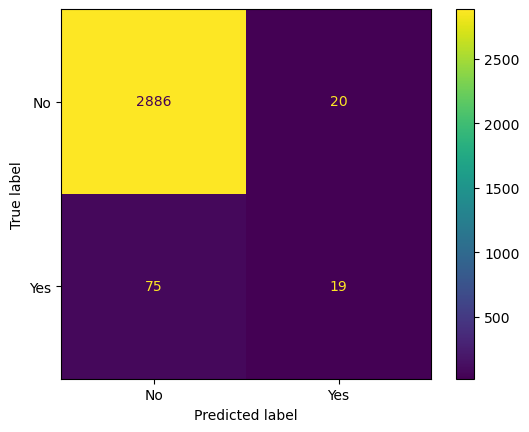

In [16]:
## Note this data is imbalanced, so accuracy is not the best metric
C = confusion_matrix(y_test, Y_pred)
ConfusionMatrixDisplay(confusion_matrix=C, display_labels=logreg.classes_).plot()

# In this case, 
#   75 people who defaulted were predicted to not default, and (company loses money)
#   20 people who didn't default were predicted to default (they don't get a loan).

## Multinomial Logistic Regression

Now we've got both multiple inputs and multiple levels. In this case we're going to use the `iris` data set but we're just going to use the version from `sklearn`. 

Take a moment to look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) or the [wikipedia page](https://en.wikipedia.org/wiki/Iris_flower_data_set) so you know what's going on in this data set. 

In [17]:
from sklearn.datasets import load_iris

In [18]:
##ANSWER##
# just to remind me what the data is about.
iris_df = load_iris(as_frame=True)['frame']
print(iris_df.head())
print(load_iris()['target_names'])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
['setosa' 'versicolor' 'virginica']


In [19]:
# I'm going to load in the data set and do a bit of processing so that it's in a nice format
iris_df = load_iris(as_frame=True)['frame']
target_names = load_iris()['target_names']
iris_df['species'] = target_names[load_iris()['target']]
iris_df.drop('target', axis=1, inplace=True)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


I've done all the hard work for you. The cell below does everything:
- Splits the data into X and y matrices. 
- Does a train/test split 
- Sets up the logistic regression classifier 
- Predicts the outputs for the test data 
- Reports an accuracy. 

*It might spit out a convergence warning for you, don't worry about it.*


In [20]:
X = iris_df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y = iris_df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=11)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

Y_pred = logreg.predict(X_test)
err = 1-accuracy_score(y_test, Y_pred)
print(f'Error rate: {err*100:.2f}%')

Error rate: 13.33%


/Users/bao/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


&#9989; **<font color=red>Do this:</font>** 
- What do the columns of `predict_proba` function below correspond to? 
- Check your answer on the first few entries. 

In [21]:
logreg.predict_proba(X_test)

array([[3.23924808e-05, 8.25704662e-02, 9.17397141e-01],
       [7.91126112e-05, 9.53513667e-02, 9.04569521e-01],
       [6.40111553e-04, 5.17334095e-01, 4.82025794e-01],
       [4.25255067e-03, 6.73997132e-01, 3.21750318e-01],
       [1.06305350e-04, 1.80263562e-01, 8.19630133e-01],
       [9.66935618e-01, 3.30642735e-02, 1.08400518e-07],
       [6.00710617e-03, 9.13850378e-01, 8.01425162e-02],
       [9.89089492e-01, 1.09104437e-02, 6.45741115e-08],
       [9.61923265e-01, 3.80765024e-02, 2.32541492e-07],
       [3.35813423e-03, 7.76634637e-01, 2.20007229e-01],
       [4.79867686e-04, 5.64867409e-01, 4.34652723e-01],
       [8.53525793e-03, 9.78920110e-01, 1.25446319e-02],
       [1.07610909e-02, 7.22993337e-01, 2.66245572e-01],
       [3.13141872e-04, 1.90952691e-01, 8.08734167e-01],
       [5.69867064e-05, 1.09670418e-01, 8.90272595e-01]])

In [22]:
##YOUR ANSWER HERE##

In [23]:
##ANSWER##
# The columns line up with the classes in the order they were in the fit function
print(f'Classes: {logreg.classes_}')
# So whichever entry in a row is the highest is the class that the model predicts
# For example, checking row 0:
i = 0
print(f'Row {i} prediction: {Y_pred[i]}')
print(f'Row {i} Probabilities: {logreg.predict_proba(X_test)[i]}')

Classes: ['setosa' 'versicolor' 'virginica']
Row 0 prediction: virginica
Row 0 Probabilities: [3.23924808e-05 8.25704662e-02 9.17397141e-01]


&#9989; **<font color=red>Q:</font>** 
Which of the classes is most often misclassified? 

In [24]:
# Your code here

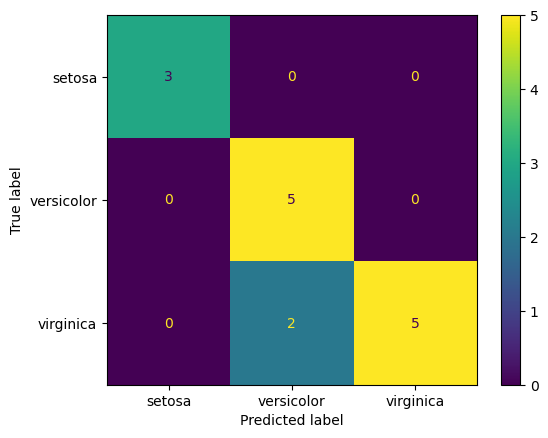

In [25]:
##ANSWER##
C = confusion_matrix(y_test, Y_pred)
ConfusionMatrixDisplay(confusion_matrix=C, display_labels=logreg.classes_).plot()
# In this case, the only error was predicting versicolor for two virginica data points



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [28]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


<IPython.core.display.Javascript object>

Myfilename CMSE381-Lec11-MoreLogisticRegression-INSTRUCTOR.ipynb


CMSE381-Lec11_MoreLogisticRegression.ipynb


Validating Notebook ./CMSE381-Lec11_MoreLogisticRegression.ipynb


c:\Users\mengs\anaconda3\Lib\site-packages\zmq\_future.py:693: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())` to avoid this warning.
  self._get_loop()



   ERROR: File Doesn't Exist - ../../DataSets/DataSets.md


3